# Links e recomendações para execução

Links necessários (caso os datasets não estejam disponíveis no repositório): 
- https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-escolar(Censo Escolar de 2024)
- https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/indicadores-educacionais/taxas-de-rendimento-escolar (Rendimento Escolar por Escola em 2024)

Esta análise foi rodada no ambiente conda, o que é prefrível para execução do ambiente

# Criação do ambiente conda para execução

```
conda create -n abandono_spark python=3.12 pyspark pandas openpyxl ipykernel -y
conda activate abandono_spark
conda install -c conda-forge openjdk=17 -y
```

Instalação dos pacotes necessários:

In [4]:
%pip install --only-binary=:all: pyspark pandas openpyxl matplotlib seaborn #Talvez não precise da flag only-binary, mas é bom para evitar problemas de compilação em algumas máquinas.

Note: you may need to restart the kernel to use updated packages.


# Definindo variáveis de path e parâmetros

In [5]:
microdados_path = "data/microdados_censo_escolar_2024_defeso/dados/microdados_ed_basica_2024.csv"
tx_rendimento_path = "data/tx_rend_escolas_2024_convertido.csv"
pre_tx_rendimento_path = "data/tx_rend_escolas_2024.xlsx"

pre_tx_rendimento_header = 8

# Conversão dos arquivos XLSX/ODS para CSV

In [6]:
import pandas as pd
import os

print("Iniciando conversão do Excel para CSV...")

# 1. Lendo o Excel usando Pandas. 
df_pandas = pd.read_excel(pre_tx_rendimento_path, sheet_name='ESCOLAS', header=pre_tx_rendimento_header)

# 2. Salvando como CSV (separado por ponto e vírgula, padrão no Brasil)
df_pandas.to_csv(tx_rendimento_path, sep=";", index=False, encoding="utf-8")

print(f"Conversão concluída! Arquivo salvo como: {tx_rendimento_path}")

Iniciando conversão do Excel para CSV...
Conversão concluída! Arquivo salvo como: data/tx_rend_escolas_2024_convertido.csv


# Iniciando o Spark 

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, regexp_replace

# Criando a sessão do Spark com paralelismo total
spark = SparkSession.builder \
    .appName("Pipeline_Evasao_Escolar") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Sessão Spark iniciada com sucesso!")
print("Versão do Spark:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/09 20:50:56 WARN Utils: Your hostname, davis-x8664, resolves to a loopback address: 127.0.1.1; using 192.168.0.12 instead (on interface wlan0)
26/07/09 20:50:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/09 20:50:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sessão Spark iniciada com sucesso!
Versão do Spark: 4.1.1


# Fazendo a ingestão dos dados

In [8]:
# Ingestão da base de Infraestrutura
df_infra = spark.read.csv(microdados_path, header=True, sep=";")

# Ingestão da base de Rendimento 
df_rend = spark.read.csv(tx_rendimento_path, header=True, sep=";")

In [9]:
print("--- Nomes das Colunas detectadas no Spark ---")
print(df_rend.columns[:15]) # Mostra as 15 primeiras colunas

print("--- Primeiras 3 linhas dos dados brutos ---")
df_rend.show(3, truncate=False)

--- Nomes das Colunas detectadas no Spark ---
['NU_ANO_CENSO', 'NO_REGIAO', 'SG_UF', 'CO_MUNICIPIO', 'NO_MUNICIPIO', 'CO_ENTIDADE', 'NO_ENTIDADE', 'NO_CATEGORIA', 'NO_DEPENDENCIA', '1_CAT_FUN', '1_CAT_FUN_AI', '1_CAT_FUN_AF', '1_CAT_FUN_01', '1_CAT_FUN_02', '1_CAT_FUN_03']
--- Primeiras 3 linhas dos dados brutos ---


26/07/09 20:51:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------+-----+------------+---------------------+-----------+---------------------+------------+--------------+---------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+---------+------------+------------+------------+------------+------------+---------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+---------+------------+------------+------------+------------+------------+---------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+------------+---------+------------+------------+------------+------------+------------+
|NU_ANO_CENSO|NO_REGIAO|SG_UF|CO_MUNICIPIO|NO_MUNICIPIO         |CO_ENTIDADE|NO_ENTIDADE          |NO_CATEGORIA|NO_DEPENDENCIA|1_CAT_FUN|1_CAT_FUN_AI|1_CAT_FUN_AF|1_CAT_FUN_01|1_CAT_FUN_02

In [10]:
from pyspark.sql.functions import col

# Conversão de ambas as bases para long (padronização)
df_rend = df_rend.withColumn("CO_ENTIDADE", col("CO_ENTIDADE").cast("double").cast("long"))
df_infra = df_infra.withColumn("CO_ENTIDADE", col("CO_ENTIDADE").cast("double").cast("long"))

# Limpeza de rodapé e não-nulos
df_infra = df_infra.filter(col("CO_ENTIDADE").isNotNull())
df_rend = df_rend.filter(col("CO_ENTIDADE").isNotNull())

print(f"Linhas em Infraestrutura após limpeza: {df_infra.count()}")
print(f"Linhas em Rendimento após limpeza: {df_rend.count()}")

Linhas em Infraestrutura após limpeza: 215545
Linhas em Rendimento após limpeza: 128096


# Análise dos Dados

## Cruzamento de dados (ESCOLA X RENDIMENTO)

In [15]:
from pyspark.sql.functions import col, when, lit, avg
import matplotlib.pyplot as plt
import seaborn as sns

print("Limpando e convertendo as taxas...")

# Criamos uma pequena função para não ter que repetir o código de limpeza toda hora
def limpar_e_converter(nome_coluna):
    # Se o valor for "--", retorna nulo (None). Caso contrário, pega o valor e converte para double.
    return when(col(nome_coluna) == "--", lit(None)) \
           .otherwise(col(nome_coluna)) \
           .cast("double")

# Aplicamos a limpeza e criamos o DataFrame numérico
df_rend_numerico = df_rend \
    .withColumn("taxa_abandono_medio", limpar_e_converter("3_CAT_MED")) \
    .withColumn("taxa_reprovacao_medio", limpar_e_converter("2_CAT_MED")) \
    .withColumn("taxa_abandono_fundamental", limpar_e_converter("3_CAT_FUN"))

# Executa o Join
df_analise = df_infra.join(df_rend_numerico, on="CO_ENTIDADE", how="inner")

print("Join realizado com sucesso!")
print(f"Total de escolas combinadas no DataFrame final: {df_analise.count()}")

Limpando e convertendo as taxas...
Join realizado com sucesso!
Total de escolas combinadas no DataFrame final: 128096


## Tecnologia e Conectividade vs. Abandono

In [16]:
df_analise.groupBy("IN_INTERNET_ALUNOS") \
    .agg({"taxa_abandono_medio": "avg", "CO_ENTIDADE": "count"}) \
    .withColumnRenamed("avg(taxa_abandono_medio)", "Media_Abandono_Ens_Medio") \
    .withColumnRenamed("count(CO_ENTIDADE)", "Total_Escolas") \
    .show()

+------------------+-------------+------------------------+
|IN_INTERNET_ALUNOS|Total_Escolas|Media_Abandono_Ens_Medio|
+------------------+-------------+------------------------+
|                 0|        63857|      3.5100573065902565|
|                 1|        64239|       2.360684925484679|
+------------------+-------------+------------------------+



  IN_INTERNET_ALUNOS  Media_Abandono
0                  0        3.510057
1                  1        2.360685


/tmp/ipykernel_123644/2314788806.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='IN_INTERNET_ALUNOS', y='Media_Abandono', data=df_internet_pd, palette="Blues_r")


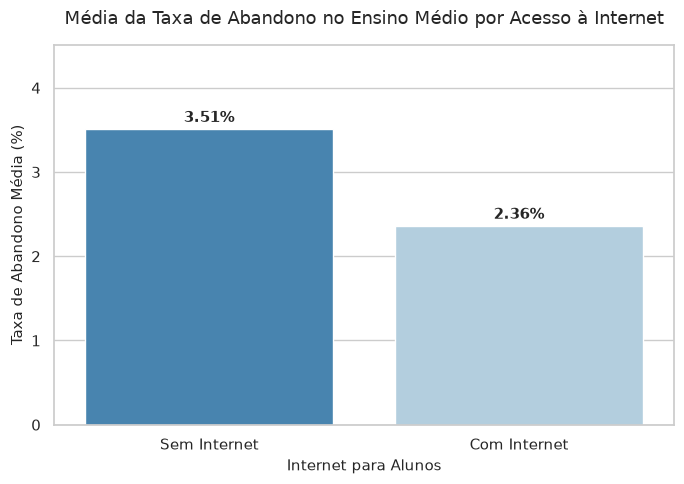

In [19]:
# 1. Agrega os dados reais no Spark e converte para Pandas
df_internet_pd = df_analise.groupBy("IN_INTERNET_ALUNOS") \
                           .agg(avg("taxa_abandono_medio").alias("Media_Abandono")) \
                           .toPandas()

print(df_internet_pd)

# 2. MAPEAMENTO SEGURO: Mapeamos considerando se o dado veio como texto, int ou float
mapeamento = {
    0: 'Sem Internet', '0': 'Sem Internet', 0.0: 'Sem Internet',
    1: 'Com Internet', '1': 'Com Internet', 1.0: 'Com Internet'
}
df_internet_pd['IN_INTERNET_ALUNOS'] = df_internet_pd['IN_INTERNET_ALUNOS'].map(mapeamento)

# Remove possíveis linhas que ficaram totalmente sem correspondência ou nulas
df_internet_pd = df_internet_pd.dropna(subset=['IN_INTERNET_ALUNOS', 'Media_Abandono'])

# 3. Configura e gera o gráfico
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

# Forçamos o tipo do gráfico de barras explicitando os eixos x e y
ax = sns.barplot(x='IN_INTERNET_ALUNOS', y='Media_Abandono', data=df_internet_pd, palette="Blues_r")

# Adicionando os valores em cima das barras de forma segura
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Garante que o valor existe antes de escrever
        ax.annotate(f"{altura:.2f}%", (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11, fontweight='bold')

plt.title('Média da Taxa de Abandono no Ensino Médio por Acesso à Internet', fontsize=13, pad=15)
plt.xlabel('Internet para Alunos', fontsize=11)
plt.ylabel('Taxa de Abandono Média (%)', fontsize=11)

# Ajuste dinâmico seguro do eixo Y (caso o máximo seja nulo, define um padrão de 0 a 5)
max_valor = df_internet_pd['Media_Abandono'].max()
plt.ylim(0, max_valor + 1 if pd.notnull(max_valor) else 5)

plt.tight_layout()
plt.show()
plt.show()

## Saneamento e Dignidade vs. Rendimento Geral

In [ ]:
df_analise.groupBy("TP_LOCALIZACAO", "IN_BIBLIOTECA") \
    .agg({"taxa_abandono_fundamental": "avg"}) \
    .show()

+--------------+-------------+------------------------------+
|TP_LOCALIZACAO|IN_BIBLIOTECA|avg(taxa_abandono_fundamental)|
+--------------+-------------+------------------------------+
|             1|            1|            0.5184148206620949|
|             2|            0|            1.1302479072762404|
|             2|            1|            0.7722957198443582|
|             1|            0|           0.48749191884986026|
+--------------+-------------+------------------------------+



## Recursos Pedagógicos e Atratividade vs. Evasão

In [ ]:
correlacao = df_analise.stat.corr("taxa_reprovacao_medio", "taxa_abandono_medio")
print(f"Correlação entre Reprovação e Abandono no Ensino Médio: {correlacao}")

Correlação entre Reprovação e Abandono no Ensino Médio: 0.3883711853649738


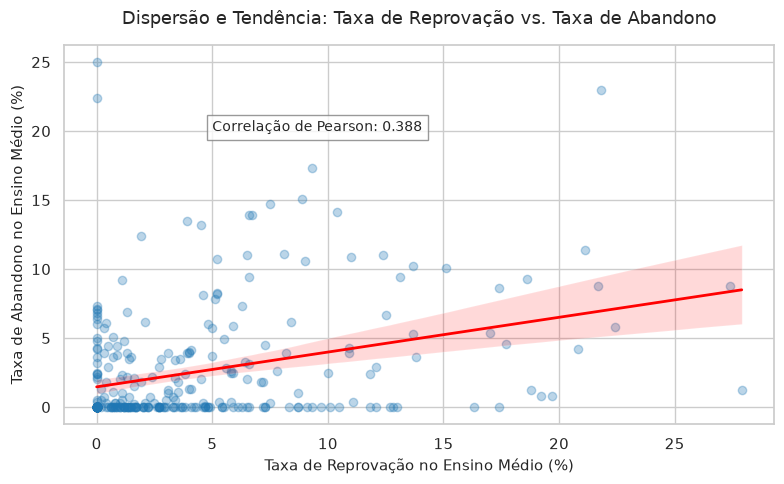

In [20]:
# Como a base final (df_analise) tem milhares de linhas, coletar tudo pro Pandas pode travar a memória.
# O truque ideal aqui é tirar uma amostra aleatória direto no Spark antes de converter:

df_amostra_pd = df_analise.select("taxa_reprovacao_medio", "taxa_abandono_medio") \
                          .dropna() \
                          .sample(withReplacement=False, fraction=0.01, seed=42) \
                          .toPandas()

plt.figure(figsize=(8, 5))

# O regplot do seaborn calcula e desenha a linha de tendência automaticamente
sns.regplot(x='taxa_reprovacao_medio', y='taxa_abandono_medio', data=df_amostra_pd,
            scatter_kws={'alpha':0.3, 'color': '#1f77b4'}, line_kws={'color': 'red', 'linewidth': 2})

plt.title('Dispersão e Tendência: Taxa de Reprovação vs. Taxa de Abandono', fontsize=13, pad=15)
plt.xlabel('Taxa de Reprovação no Ensino Médio (%)', fontsize=11)
plt.ylabel('Taxa de Abandono no Ensino Médio (%)', fontsize=11)

# Adiciona uma caixa de texto indicando o valor exato da correlação que você calculou
plt.text(5, df_amostra_pd['taxa_abandono_medio'].max() * 0.8, 
         'Correlação de Pearson: 0.388', 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'), fontsize=10)

plt.tight_layout()
plt.show()

## Vulnerabilidade de Localização (Corte Geográfico)

In [ ]:
# Criando uma pontuação de 0 a 4 para a estrutura pedagógica da escola
df_com_indice = df_analise.withColumn(
    "score_pedagogico",
    col("IN_BIBLIOTECA").cast("int") +
    col("IN_LABORATORIO_CIENCIAS").cast("int") +
    col("IN_LABORATORIO_INFORMATICA").cast("int") +
    col("IN_QUADRA_ESPORTES").cast("int")
)

# Comparando a média de abandono por faixa de pontuação da escola
df_com_indice.groupBy("score_pedagogico") \
    .agg({"taxa_abandono_medio": "avg"}) \
    .orderBy("score_pedagogico") \
    .show()

+----------------+------------------------+
|score_pedagogico|avg(taxa_abandono_medio)|
+----------------+------------------------+
|               0|       4.889119170984458|
|               1|      3.0291025641025646|
|               2|       2.728735632183908|
|               3|      2.4909079724409455|
|               4|      2.0991318726746586|
+----------------+------------------------+

